In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from lo_tools import Lfun, zfun

In [5]:
ds_processed_mouth = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/mouth.nc')
ds_processed_1 = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/1.nc')
ds_processed_2 = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/2.nc')
ds_processed_3 = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/3.nc')
ds_processed_4 = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/4.nc')

print(ds_processed_mouth)

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 1465, sbins: 1000)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2020-01-15 ... 2020-03-16
  * sbins    (sbins) float64 8kB 0.018 0.054 0.09 0.126 ... 35.91 35.95 35.98
Data variables:
    qnet     (time) float64 12kB ...
    fnet     (time) float64 12kB ...
    ssh      (time) float64 12kB ...
    salt     (time, sbins) float64 12MB ...
    q        (time, sbins) float64 12MB ...
    salt2    (time, sbins) float64 12MB ...


In [7]:
def calc_Qin_Qout(ds):
    q = ds['q'].values   # (time, sbins)

    # Qin/Qout at each time
    Qin  = np.sum(np.where(q > 0, q, 0), axis=1)
    Qout = np.sum(np.where(q < 0, q, 0), axis=1)

    return Qin.mean(), Qout.mean()

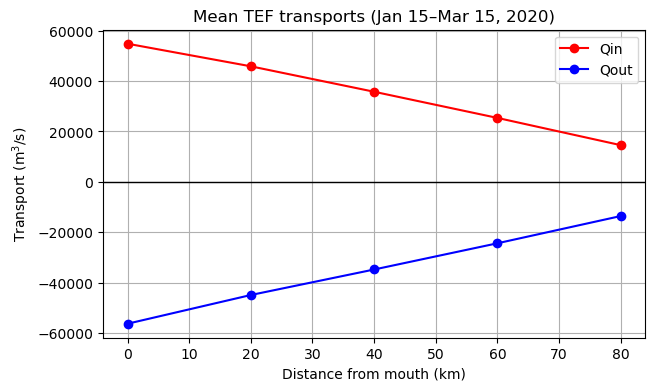

In [10]:
# assign distances
dist_km = {
    "mouth": 0,
    "1": 80,
    "2": 60,
    "3": 40,
    "4": 20
}

sections = {
    "mouth": ds_processed_mouth,
    "1": ds_processed_1,
    "2": ds_processed_2,
    "3": ds_processed_3,
    "4": ds_processed_4
}

dist_list = []
Qin_list = []
Qout_list = []

for name, ds in sections.items():
    Qin_mean, Qout_mean = calc_Qin_Qout(ds)

    dist_list.append(dist_km[name])
    Qin_list.append(Qin_mean)
    Qout_list.append(Qout_mean)

# sort by distance
dist_list = np.array(dist_list)
Qin_list = np.array(Qin_list)
Qout_list = np.array(Qout_list)

ii = np.argsort(dist_list)
dist_list = dist_list[ii]
Qin_list = Qin_list[ii]
Qout_list = Qout_list[ii]

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(dist_list, Qin_list, '-o', label='Qin', color='red')
plt.plot(dist_list, Qout_list, '-o', label='Qout', color='blue')

plt.axhline(0, color='k', lw=1)
plt.xlabel('Distance from mouth (km)')
plt.ylabel('Transport (m$^3$/s)')
plt.title('Mean TEF transports (Jan 15–Mar 15, 2020)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
dist_km = {
    "mouth": 0,
    "1": 80,
    "2": 60,
    "3": 40,
    "4": 20
}

sections = {
    "mouth": ds_processed_mouth,
    "1": ds_processed_1,
    "2": ds_processed_2,
    "3": ds_processed_3,
    "4": ds_processed_4
}

dist_list = []
F_list = []

for name, ds in sections.items():
    F_mean = ds['fnet'].mean().item()

    dist_list.append(dist_km[name])
    F_list.append(F_mean)

# sort by distance
dist_list = np.array(dist_list)
F_list = np.array(F_list)

ii = np.argsort(dist_list)
dist_list = dist_list[ii]
F_list = F_list[ii]

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(dist_list, F_list, '-o', color='purple', label='Salt flux (fnet)')

plt.axhline(0, color='k', lw=1)
plt.xlabel('Distance from mouth (km)')
plt.ylabel('Salt flux (kg/s or psu·m³/s)')
plt.title('Mean TEF Salt Flux (fnet)')
plt.grid(True)
plt.legend()
plt.show()